In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#import libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [ ]:
df = pd.read_excel('/content/Data Analysis - Dataset for Fortunate.xlsx')

In [ ]:
df.head()


,Questionnaire_ID,District,Age,age group,Sex,Occupation,Other_Occupation_Specify,Listened to SRHR Messages,No of messages recalled,Messages recalled_Option 1,Messages recalled_Option 2,Messages recalled_Option 3,Satisfied with service,Service comprehesive,H/w knowlegeable,H/w caring,Money(UGX) spent on health
0,PATH 001,Mukono,11,10-14yrs,Female,Student/Pupil,NaN,Yes,1,HIV/STIs prevention (ABC),NaN,NaN,3,2.0,3.0,2.0,278400
1,PATH 002,Mukono,11,10-14yrs,Female,Student/Pupil,NaN,Yes,2,Maralia Prevention,Immunisation,NaN,2,3.0,2.0,1.0,309440
2,path 003,Mukono,12,10-14yrs,Male,Student/Pupil,NaN,No,0,NaN,NaN,NaN,3,2.0,3.0,2.0,2880
3,PATH 004,Mukono,12,10-14yrs,Female,Student/Pupil,NaN,Yes,2,Immunisation,HIV/STIs prevention (ABC),NaN,0,0.0,0.0,0.0,169600
4,PATH 005,Mukono,14,10-14yrs,Male,Student/Pupil,NaN,Yes,1,HIV/STIs prevention (ABC),NaN,NaN,3,3.0,3.0,3.0,137600


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3416 entries, 0 to 3415
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Questionnaire_ID            3416 non-null   object 
 1   District                    3416 non-null   object 
 2   Age                         3416 non-null   int64  
 3   age group                   3416 non-null   object 
 4   Sex                         3416 non-null   object 
 5   Occupation                  3247 non-null   object 
 6   Other_Occupation_Specify    270 non-null    object 
 7   Listened to SRHR Messages   3374 non-null   object 
 8   No of messages recalled     3416 non-null   int64  
 9   Messages recalled_Option 1  2628 non-null   object 
 10  Messages recalled_Option 2  1917 non-null   object 
 11  Messages recalled_Option 3  788 non-null    object 
 12  Satisfied with service      3416 non-null   int64  
 13  Service comprehesive        3415 

In [ ]:
df.describe()


,Age,No of messages recalled,Satisfied with service,Service comprehesive,H/w knowlegeable,H/w caring,Money(UGX) spent on health
count,3416.000000,3416.000000,3416.000000,3415.000000,3415.000000,3415.000000,3.416000e+03
mean,18.711066,1.561183,2.403103,2.363104,2.538507,2.479649,2.471859e+05
std,7.647655,1.072648,0.789003,0.851917,0.788517,0.806450,1.072485e+06
min,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,14.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.880000e+04
50%,18.000000,2.000000,3.000000,3.000000,3.000000,3.000000,7.488000e+04
75%,22.000000,2.000000,3.000000,3.000000,3.000000,3.000000,1.603200e+05
max,89.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.968000e+07


In [ ]:
df.isnull().sum()

,0
Questionnaire_ID,0
District,0
Age,0
age group,0
Sex,0
Occupation,169
Other_Occupation_Specify,3146
Listened to SRHR Messages,42
No of messages recalled,0
Messages recalled_Option 1,788


**Univariate Visualization 1: **Age Distribution (Histogram)
Purpose

Shows how respondents are distributed across different ages.

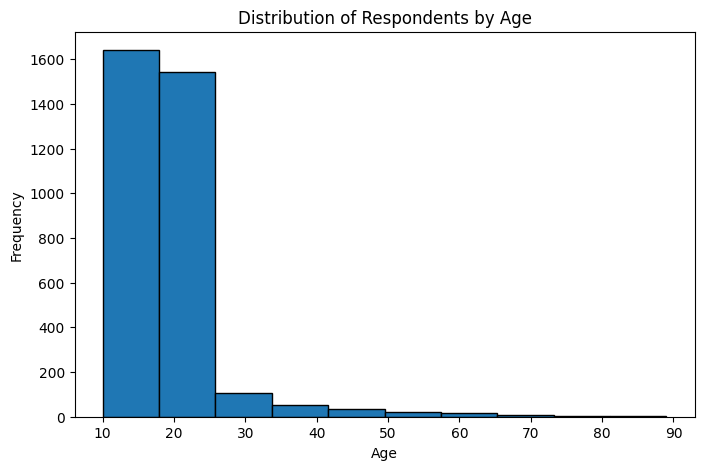

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=10, edgecolor='black')
plt.title('Distribution of Respondents by Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

*The histogram shows the age distribution of the respondents. Most pupils are concentrated within the dominant age range, indicating that the survey mainly targeted pupils in that age group.*

**Multivariate Visualization 1:** Listening to SRHR Messages by Gender
Purpose

Compares the target variable across male and female pupils.

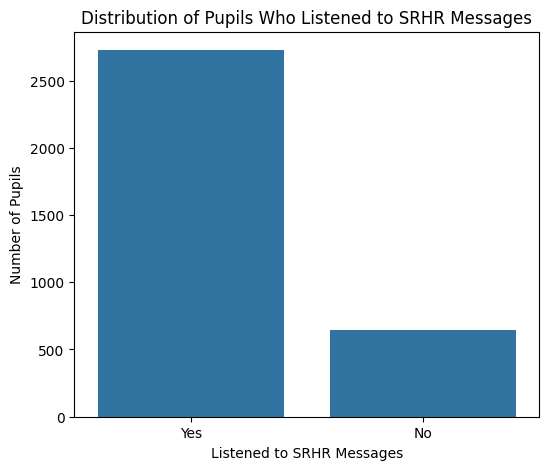

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.countplot(x='Listened to SRHR Messages', data=df)
plt.title('Distribution of Pupils Who Listened to SRHR Messages')
plt.xlabel('Listened to SRHR Messages')
plt.ylabel('Number of Pupils')
plt.show()

*This visualization compares the number of male and female pupils who listened to SRHR messages. It helps determine whether exposure to SRHR messages differs by gender.*

***Multivariate Visualization 2:*** Listening to SRHR Messages by District
Purpose

Compares exposure across districts.

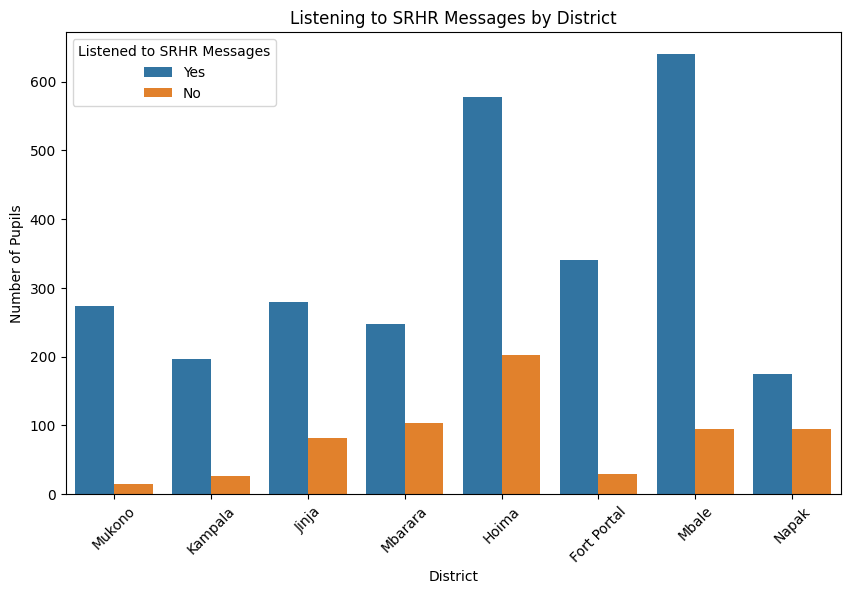

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='District',
              hue='Listened to SRHR Messages',
              data=df)

plt.title('Listening to SRHR Messages by District')
plt.xlabel('District')
plt.ylabel('Number of Pupils')
plt.xticks(rotation=45)
plt.show()

*This chart compares the number of pupils who listened to SRHR messages across different districts. Differences may indicate variations in program implementation or outreach.*

**Data Cleaning**
Step 1: Check for Missing Values

In [ ]:
# Check for missing values in each column
df.isnull().sum()

,0
Questionnaire_ID,0
District,0
Age,0
age group,0
Sex,0
Occupation,169
Other_Occupation_Specify,3146
Listened to SRHR Messages,42
No of messages recalled,0
Messages recalled_Option 1,788


In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Sex'] = df['Sex'].fillna(df['Sex'].mode()[0])

**Remove Duplicate Records**

Check for duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

**Encode Categorical Variables**

Machine learning models require numerical values instead of text.

In [ ]:
df.dtypes


,0
Questionnaire_ID,object
District,object
Age,int64
age group,object
Sex,object
Occupation,object
Other_Occupation_Specify,object
Listened to SRHR Messages,object
No of messages recalled,int64
Messages recalled_Option 1,object


In [ ]:
df = df.dropna(subset=['Listened to SRHR Messages']).copy()

In [ ]:
X = df.drop(columns=['Listened to SRHR Messages'])
y = df['Listened to SRHR Messages']

In [ ]:
X = X.drop(columns=[
    'Questionnaire_ID',
    'Other_Occupation_Specify',
    'Messages recalled_Option 1',
    'Messages recalled_Option 2',
    'Messages recalled_Option 3'
])

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
print(X.dtypes)

Age                                     int64
No of messages recalled                 int64
Satisfied with service                  int64
Service comprehesive                  float64
H/w knowlegeable                      float64
H/w caring                            float64
Money(UGX) spent on health              int64
District_Hoima                           bool
District_Jinja                           bool
District_Kampala                         bool
District_Mbale                           bool
District_Mbarara                         bool
District_Mukono                          bool
District_Napak                           bool
age group_15-19yrs                       bool
age group_20-24yrs                       bool
age group_25+yrs                         bool
Sex_Male                                 bool
Sex_female                               bool
Sex_male                                 bool
Occupation_Bodaboda                      bool
Occupation_Business man/woman     

In [ ]:
X['Service comprehesive'] = X['Service comprehesive'].fillna(
    X['Service comprehesive'].median()
)

X['H/w knowlegeable'] = X['H/w knowlegeable'].fillna(
    X['H/w knowlegeable'].median()
)

X['H/w caring'] = X['H/w caring'].fillna(
    X['H/w caring'].median()
)

In [ ]:
print(X.isnull().sum().sum())

0


In [ ]:
print("Missing values:", X.isnull().sum().sum())
print("Text columns:", X.select_dtypes(include='object').columns.tolist())

Missing values: 0
Text columns: []


In [ ]:
X.isnull().sum()[X.isnull().sum() > 0]
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

Missing values in X: 0
Missing values in y: 0


**Evaluate the model**

In [ ]:
# from sklearn.metrics import accuracy_score, classification_report

# accuracy_rf = accuracy_score(y_test, y_pred_rf)

# print("Random Forest Accuracy:", accuracy_rf)
# print()
# print(classification_report(y_test, y_pred_rf))

**Report Interpretation**

Numerical features were standardized using StandardScaler so that they have a mean of zero and a standard deviation of one. This ensures that features with larger values do not dominate the learning process.

Define the Target Variable (y)

Define the Predictor Variables (X)

In [ ]:
# y = df['Listened to SRHR Messages']
# X = df.drop('Listened to SRHR Messages', axis=1)
# Separate predictors (X) and target (y)

X = df.drop(columns=[
    'Listened to SRHR Messages',
    'Questionnaire_ID',
    'Other_Occupation_Specify'
])

y = df['Listened to SRHR Messages']

In [ ]:
X.isnull().sum()

,0
District,0
Age,0
age group,0
Sex,0
Occupation,148
No of messages recalled,0
Messages recalled_Option 1,763
Messages recalled_Option 2,1473
Messages recalled_Option 3,2593
Satisfied with service,0


In [ ]:
# Fill numerical columns with the median
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

X[numerical_cols] = X[numerical_cols].fillna(
    X[numerical_cols].median()
)

# Fill categorical columns with "Unknown"
categorical_cols = X.select_dtypes(include='object').columns

X[categorical_cols] = X[categorical_cols].fillna('Unknown')

In [ ]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

In [ ]:
print(X.isnull().sum().sum())

0


In [ ]:
df['Listened to SRHR Messages'].value_counts()

,count
Listened to SRHR Messages,
Yes,2727
No,647


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2699, 82)
X_test: (675, 82)
y_train: (2699,)
y_test: (675,)


test_size=0.2 → 20% of the data is reserved for testing, while 80% is used for training.

random_state=42 → ensures that the split is reproducible.

**Checking the split**

In [ ]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (2699, 82)
Testing Features: (675, 82)
Training Labels: (2699,)
Testing Labels: (675,)


In [ ]:
df['Listened to SRHR Messages'].unique()

array(['Yes', 'No'], dtype=object)

**Machine Learning Models**
**Model 1: Random Forest Classifier**
*Why Random Forest?*

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is well suited for classification tasks such as predicting whether pupils have listened to SRHR messages.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)



RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

print(y_pred_rf[:20])

['Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'No' 'Yes'
 'No' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'No']


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)
print()
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9718518518518519

              precision    recall  f1-score   support

          No       0.92      0.94      0.93       129
         Yes       0.99      0.98      0.98       546

    accuracy                           0.97       675
   macro avg       0.95      0.96      0.95       675
weighted avg       0.97      0.97      0.97       675



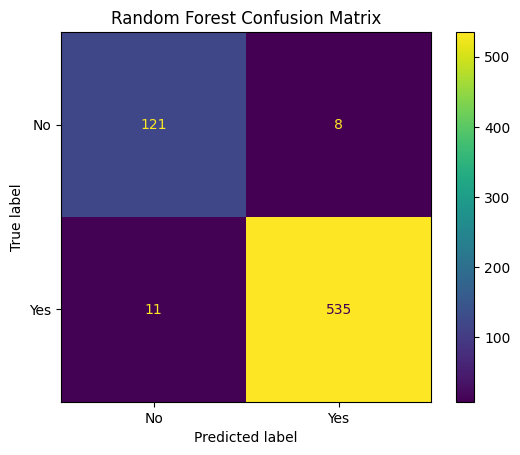

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("Random Forest Confusion Matrix")
plt.show()

A Random Forest classifier was trained to predict whether pupils had listened to SRHR messages. The model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. These metrics measured the model's ability to correctly classify pupils based on the predictor variables.

**Neural Network using TensorFlow/Keras.**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
print(tf.__version__)

2.20.0


**Build the neural network**

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

What each layer does

Input Layer
Receives all the predictor variables in your dataset.

First hidden layer
Contains 64 neurons and uses ReLU to learn patterns in the data.

Second hidden layer
Contains 32 neurons and learns more complex relationships.

Output layer
Produces a probability between 0 and 1.

Compile the Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

**Why these are used**

Adam → adjusts the model's learning during training.

Binary cross-entropy → appropriate because I am predicting two classes (0 and 1).

Accuracy → measures the proportion of correct predictions.

In [ ]:
y_train_nn = y_train.map({
    'No': 0,
    'Yes': 1
}).astype('float32')

y_test_nn = y_test.map({
    'No': 0,
    'Yes': 1
}).astype('float32')

In [ ]:
print(y_train_nn.unique())
print(y_test_nn.unique())

[1. 0.]
[1. 0.]


In [ ]:
X_train_nn = np.asarray(X_train).astype('float32')
X_test_nn = np.asarray(X_test).astype('float32')

In [ ]:
history = model.fit(
    X_train_nn,
    y_train_nn,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6461 - loss: 1017.3349 - val_accuracy: 0.8037 - val_loss: 114.9375
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6610 - loss: 347.4044 - val_accuracy: 0.8037 - val_loss: 94.1735
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7050 - loss: 249.2066 - val_accuracy: 0.2370 - val_loss: 640.0918
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6457 - loss: 566.9685 - val_accuracy: 0.8037 - val_loss: 1028.4769
Epoch 5/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6938 - loss: 388.8972 - val_accuracy: 0.8037 - val_loss: 332.4517
Epoch 6/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6836 - loss: 348.0892 - val_accuracy: 0.3167 - val_loss: 60.2688
Epoch 7/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6790 - loss: 184.3209 - val_accuracy: 0.8037 - val_loss: 44.2110
Epoch 8/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7063 - loss: 131.9289 - val

**Predict**

In [ ]:
y_pred_prob = model.predict(X_test_nn)

y_pred_nn = (y_pred_prob >= 0.5).astype(int).ravel()

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


**Evaluate**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Neural Network Accuracy:",
      accuracy_score(y_test_nn, y_pred_nn))

print(classification_report(y_test_nn, y_pred_nn))

Neural Network Accuracy: 0.4177777777777778
              precision    recall  f1-score   support

         0.0       0.23      0.90      0.37       129
         1.0       0.93      0.30      0.46       546

    accuracy                           0.42       675
   macro avg       0.58      0.60      0.41       675
weighted avg       0.79      0.42      0.44       675



In [ ]:
print(X.columns.tolist())

['Age', 'No of messages recalled', 'Satisfied with service', 'Service comprehesive', 'H/w knowlegeable', 'H/w caring', 'Money(UGX) spent on health', 'District_Hoima', 'District_Jinja', 'District_Kampala', 'District_Mbale', 'District_Mbarara', 'District_Mukono', 'District_Napak', 'age group_15-19yrs', 'age group_20-24yrs', 'age group_25+yrs', 'Sex_Male', 'Sex_female', 'Sex_male', 'Occupation_Bodaboda', 'Occupation_Business man/woman', 'Occupation_Civil servant', 'Occupation_Farmer (peasant farmer)', 'Occupation_House girl', 'Occupation_Housewife', 'Occupation_Others', 'Occupation_Student/Pupil', 'Occupation_Teacher', 'Occupation_Unknown', 'Occupation_business man/woman', 'Occupation_student/Pupil', 'Messages recalled_Option 1_Cervical cancer', 'Messages recalled_Option 1_Drug adherence', 'Messages recalled_Option 1_Family planning', 'Messages recalled_Option 1_HIV testing', 'Messages recalled_Option 1_HIV/STI testing and counselling', 'Messages recalled_Option 1_HIV/STIs prevention (ABC

In [ ]:
joblib.dump(X.columns.tolist(), 'model_columns.pkl')

['model_columns.pkl']

In [ ]:
files.download('model_columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib

joblib.dump(rf_model, 'rf_model.pkl')

['rf_model.pkl']

In [ ]:
from google.colab import files

files.download('rf_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>